In [55]:
import xsimlab as xs
import numpy as np
from fastscape.processes import StreamPowerChannel,TotalErosion,RasterGrid2D

@xs.process
class HardLayer:
    k_coef = xs.variable(dims=[(),('y','x')], description="Stream Power Law Coefficient")
    hardness = xs.variable(description="Hardness of the layer")
    depth = xs.variable(description="Depth of middle of hard layer")
    thickness = xs.variable(description="Thickness of the hard layer")
    k_coef_out = xs.foreign(StreamPowerChannel, 'k_coef', intent='out')
    erosion = xs.foreign(TotalErosion, 'cumulative_height')
    shape = xs.foreign(RasterGrid2D, 'shape')
    
    def initialize(self):
        self.k_coef_out = np.broadcast_to(self.k_coef, self.shape)
        
    def run_step(self):
        k_coef = np.broadcast_to(self.k_coef, self.shape)
        self.k_coef_out = np.where((self.erosion-self.depth-self.thickness/2)*(self.erosion-self.depth+self.thickness/2)<=0,
                                    k_coef*self.hardness, k_coef)


In [56]:
from fastscape.models import basic_model
%load_ext xsimlab.ipython
model = basic_model.update_processes({'layer':HardLayer}).drop_processes(('init_topography','uplift'))

The xsimlab.ipython extension is already loaded. To reload it, use:
  %reload_ext xsimlab.ipython


In [57]:
import xarray as xr

nx,ny = 401,301
xl,yl = 400e3,300e3
x,y = np.meshgrid(np.linspace(0,xl,nx),np.linspace(0,yl,ny))
x = xr.DataArray(x, dims=('y','x'))
y = xr.DataArray(y, dims=('y','x'))

h0 = 1000 + np.random.random((ny,nx))
hinit = xr.where(y==0, 0, h0)

tf = 70e6
nstep = 71
nout = 8

tstep = xr.DataArray(np.linspace(0,tf,nstep), dims='tstep')
time = xr.DataArray(np.linspace(0,tf,nout), dims='time')

In [66]:
# %create_setup model
import xsimlab as xs

ds_in = xs.create_setup(
    model=model,
    clocks={'tstep':tstep,
            'time':time},
    master_clock='tstep',
    input_vars={
        'grid__shape': [ny,nx],
        'grid__length': [yl,xl],
        'boundary__status': ['looped','looped','fixed_value','core'],
        'layer__k_coef': 2e-7,
        'layer__hardness': 0.2,
        'layer__depth': 250,
        'layer__thickness': 250,
        'spl__area_exp': 0.45,
        'spl__slope_exp': 1,
        'diffusion__diffusivity': 0.1,
        'topography__elevation': hinit,
    },
    output_vars={'topography__elevation': 'time',
                 'drainage__area': 'time',
                 'spl__k_coef': 'time'}
)


In [67]:
with model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run()

             0% | initialize 

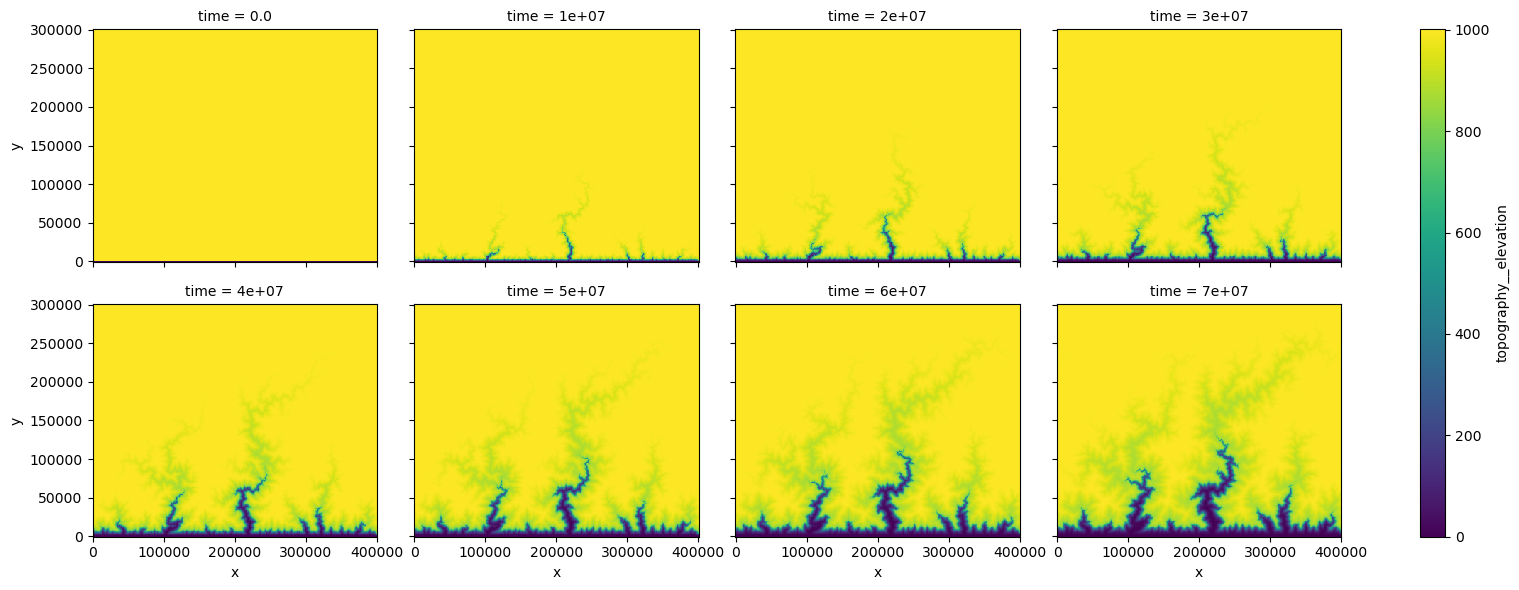

In [68]:
ds_out.topography__elevation.plot(col='time', col_wrap=4, aspect=xl/yl);

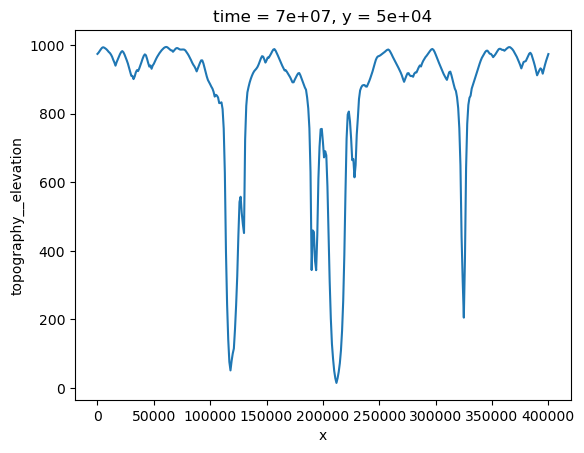

In [69]:
ds_out.topography__elevation.sel(y=50e3).isel(time=-1).plot();

In [62]:
ds_out.x.attrs["units"]= "m"
ds_out.y.attrs["units"]= "m"
ds_out.time.attrs["units"]= "years"

(ds_out.topography__elevation).to_netcdf('Topo.nc')
(ds_out.drainage__area).to_netcdf('Area.nc')
(ds_out.spl__k_coef).to_netcdf('Hardness.nc')
